## Neural Networks

A neural network is a machine learning model inspired by the way the human brain processes information. It is composed of interconnected layers of units called **neurons**, where each neuron applies a linear transformation followed by a nonlinear activation function.

Neural networks are especially useful when the relationship between inputs and outputs is **complex and nonlinear**, making simpler models such as logistic regression insufficient.

## Why do we use Neural Networks?

Logistic regression works well for problems that can be separated by a linear boundary. However, many real-world tasks — such as image recognition — involve patterns that are far more complex.

Neural networks solve this limitation by stacking multiple layers, allowing the model to automatically learn:

- low-level features (edges, contrasts)
- intermediate patterns (shapes)
- high-level structures (complete digits)

This hierarchical learning makes neural networks powerful tools for **computer vision**, speech recognition, and natural language processing.

In [1]:
import os
import numpy as np
from matplotlib import pyplot
from scipy import optimize

import utils

# tells matplotlib to embed plots within the notebook
%matplotlib inline

Previously, we implemented multi-class logistic regression to recognize handwritten digits (from 0 to 9). However, logistic regression cannot form more complex hypotheses as it is only a linear classifier (You could add more features - such as polynomial features - to logistic regression, but that can be very expensive to train).

Now, we'll implement a neural network to recognize handwritten digits using the same training set as before. The neural network will be able to represent complex models that form non-linear hypotheses.

(5000, 400)
(5000,)
[0 1 2 3 4 5 6 7 8 9]


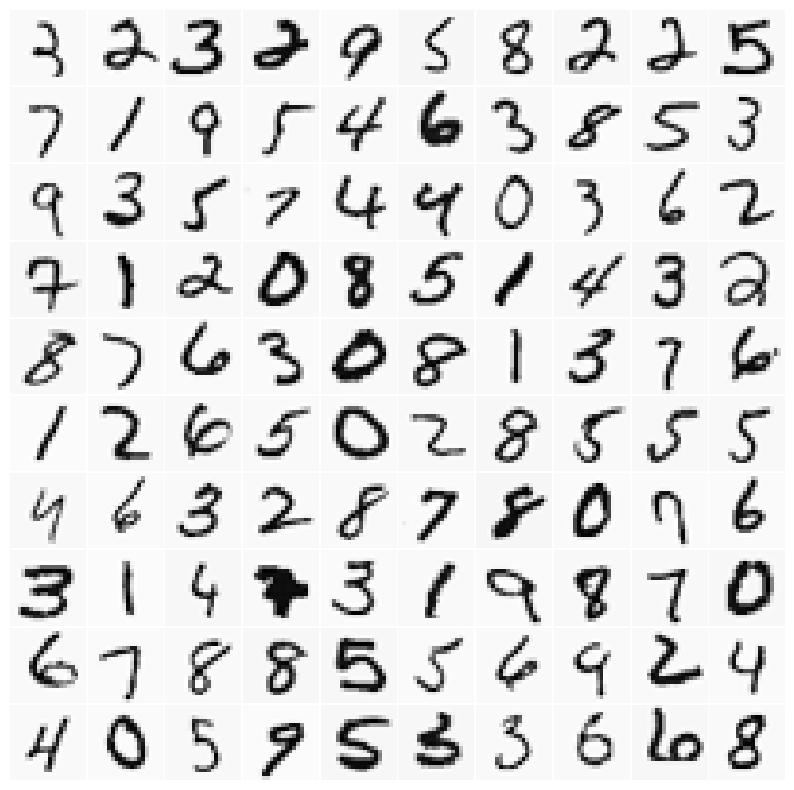

In [2]:
#  training data stored in arrays X, y
data = np.load('Data/digits_dataset.npz')

X = data['X']
y = data['y']

m = y.size

print(X.shape)
print(y.shape)
print(np.unique(y))

# get number of examples in dataset
m = y.size

# randomly permute examples, to be used for visualizing one 
# picture at a time
indices = np.random.permutation(m)

# Randomly select 100 data points to display
rand_indices = np.random.choice(m, 100, replace=False)
sel = X[rand_indices, :]

utils.displayData(sel)


### Model representation 

Our neural network has 3 layers: an input layer, a hidden layer and an output layer. Recall that our inputs are pixel values of digit images. Since the images are of size 20×20, this gives us 400 input layer units (excluding the extra bias unit which always outputs +1). As before, the training data will be loaded into the variables X and y. 

We will be using the file `network_parameters_weights.npz`, with a set of network parameters ($\Theta^{(1)}$, $\Theta^{(2)}$) already trained. 
The parameters have dimensions that are sized for a neural network with 25 units in the second layer and 10 output units (corresponding to the 10 digit classes).

In [3]:
# Setup the parameters you will use for this exercise
input_layer_size  = 400  # 20x20 Input Images of Digits
hidden_layer_size = 25   # 25 hidden units
num_labels = 10          # 10 labels, from 0 to 9

# Load npz file
weights = np.load('Data/network_parameters_weights.npz')

Theta1 = weights['Theta1']
Theta2 = weights['Theta2']

### Feedforward Propagation and Prediction

Now we will implement feedforward propagation for the neural network, that computes $h_\theta(x^{(i)})$ for every example $i$ and returns the associated predictions. Similar to the one-vs-all classification strategy, the prediction from the neural network will be the label that has the largest output $\left( h_\theta(x) \right)_k$.

In [4]:
def predict(Theta1, Theta2, X):
    """
    Predict the label of an input given a trained neural network.
    
    Parameters
    ----------
    Theta1 : array_like
        Weights for the first layer in the neural network.
        It has shape (2nd hidden layer size x input size)
    
    Theta2: array_like
        Weights for the second layer in the neural network. 
        It has shape (output layer size x 2nd hidden layer size)
    
    X : array_like
        The image inputs having shape (number of examples x image dimensions).
    
    Return 
    ------
    p : array_like
        Predictions vector containing the predicted label for each example.
        It has a length equal to the number of examples.
    
    """
    # Make sure the input has two dimensions
    if X.ndim == 1:
        X = X[None]  # promote to 2-dimensions
    
    # useful variables
    m = X.shape[0]
    num_labels = Theta2.shape[0]

    # You need to return the following variables correctly 
    p = np.zeros(X.shape[0])

    # Add ones to the X data matrix
    X = np.concatenate([np.ones((m, 1)), X], axis=1)

    # X matriz dimension: m x (n+1)    Theta1.T: input_size (num features) x second_layer_size
    a2 = utils.sigmoid(X.dot(Theta1.T))
    number_rows = a2.shape[0]
    
    # a2 dimension: m x second_layer_size   Theta2.T: second_layer_size x output_size
    a2 =  np.concatenate([np.ones((number_rows, 1)), a2], axis=1)
    # Result: m X output_size
    a3 = utils.sigmoid(a2.dot(Theta2.T))
    p  = np.argmax(a3, axis=1)
    print(f"a2: {a2.shape}")
    print(f"a3: {a3.shape}")

    return p

Call predict function using the loaded set of parameters for `Theta1` and `Theta2`. The accuracy is about 97.5%.

In [5]:
pred = predict(Theta1, Theta2, X)
print('Training Set Accuracy: {:.1f}%'.format(np.mean(pred == y) * 100))

a2: (5000, 26)
a3: (5000, 10)
Training Set Accuracy: 97.5%


After that, we will display images from the training set one at a time, while at the same time printing out the predicted label for the displayed image. 

Run the following cell to display a single image the the neural network's prediction. We can run the cell multiple times to see predictions for different images.

a2: (1, 26)
a3: (1, 10)
Neural Network Prediction: 7


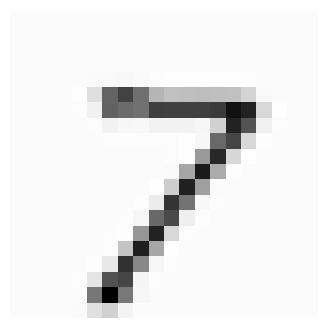

In [7]:
if indices.size > 0:
    i, indices = indices[0], indices[1:]
    utils.displayData(X[i, :], figsize=(4, 4))
    pred = predict(Theta1, Theta2, X[i, :])
    print('Neural Network Prediction: {}'.format(*pred))
else:
    print('No more images to display!')